In [ ]:
# Colab: Pakete installieren
!pip install evaluate datasets transformers huggingface_hub openai python-dotenv kaggle -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
# HuggingFace Login
from huggingface_hub import login
login(token='YOUR_HF_TOKEN')  # <-- deinen HF Token eintragen (beginnt mit hf_...)


In [ ]:
# Colab: HAM10000 von Google Drive laden
from google.colab import drive
import os, subprocess

drive.mount('/content/drive')
print('Google Drive gemountet!')

DRIVE_ARCHIVE = '/content/drive/MyDrive/archive'
result = subprocess.run(['find', DRIVE_ARCHIVE, '-name', '*.jpg', '-maxdepth', '2'], capture_output=True, text=True)
jpg_count = len([x for x in result.stdout.strip().split('\n') if x])
print(f'Gefundene JPG Bilder in Drive: {jpg_count}')


Mounted at /content/drive
Google Drive gemountet!
Gefundene JPG Bilder in Drive: 10015


In [ ]:
# Colab: metadata_with_split.csv erstellen (mit Google Drive Pfaden)
import pandas as pd, os
from pathlib import Path
from sklearn.model_selection import train_test_split

ham_dir = Path('/content/drive/MyDrive/archive')

meta_candidates = list(ham_dir.rglob('HAM10000_metadata.csv'))
if not meta_candidates:
    raise FileNotFoundError('HAM10000_metadata.csv nicht gefunden!')
meta = pd.read_csv(meta_candidates[0])
print(f'Metadata geladen: {len(meta)} Zeilen')

img_dirs = [p for p in ham_dir.rglob('*') if p.is_dir() and 'images' in p.name.lower()]
if not img_dirs:
    img_dirs = [ham_dir]

def find_image(image_id):
    for d in img_dirs:
        p = d / f'{image_id}.jpg'
        if p.exists():
            return str(p)
    results = list(ham_dir.rglob(f'{image_id}.jpg'))
    return str(results[0]) if results else None

meta['image_path'] = meta['image_id'].apply(find_image)
meta = meta[meta['image_path'].notna()].copy()
print(f'Bilder gefunden: {len(meta)}')

_, test_df = train_test_split(meta, test_size=0.2, stratify=meta['dx'], random_state=42)
meta['split'] = 'train'
meta.loc[test_df.index, 'split'] = 'test'

os.makedirs('/content/data/processed', exist_ok=True)
os.makedirs('/content/reports/figures', exist_ok=True)
os.makedirs('/content/models', exist_ok=True)
meta.to_csv('/content/data/processed/metadata_with_split.csv', index=False)
print(meta['split'].value_counts())
print(meta['dx'].value_counts())


Metadata geladen: 10015 Zeilen
Bilder gefunden: 10015
split
train    8012
test     2003
Name: count, dtype: int64
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


# Notebook 3: Computer Vision — Transfer Learning & Model Comparison
**Skin Lesion Risk Advisor**

⚠️ **Empfehlung: Auf Google Colab mit GPU ausführen!**

Wir trainieren ein ViT-Modell auf den HAM10000-Bildern und vergleichen anschliessend:
1. **Unser ViT** (fine-tuned auf HAM10000)
2. **CLIP** (Zero-Shot, kein Training nötig)
3. **OpenAI Vision** (GPT-4o-mini mit Bildverständnis)

Gleicher Ansatz wie in den Kursübungen (Week 6–8).

## 0. Setup

In [ ]:
import os
import json
import base64
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer
)
from transformers import pipeline
import evaluate
from openai import OpenAI
from dotenv import load_dotenv

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# load_dotenv('../.env')  # Colab: .env nicht nötig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

FIGURES_DIR = Path('/content/reports/figures')
MODELS_DIR  = Path('/content/models')
ARCHIVE     = Path('/content/ham10000')

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID2LABEL = {i: c for i, c in enumerate(CLASS_NAMES)}

HF_USERNAME = 'PREMAADC'
MODEL_NAME  = f'{HF_USERNAME}/vit-base-ham10000'

print('Setup OK')

Device: cuda
Setup OK


## 1. Daten laden & HuggingFace Dataset erstellen

In [ ]:
df = pd.read_csv('/content/data/processed/metadata_with_split.csv')
df = df[df['image_path'].notna()].copy()

df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_test  = df[df['split'] == 'test'].reset_index(drop=True)

print(f'Train: {len(df_train)}, Test: {len(df_test)}')
print('Klassenverteilung Train:')
print(df_train['dx'].value_counts())


Train: 8012, Test: 2003
Klassenverteilung Train:
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64


In [ ]:
def df_to_hf_dataset(df):
    return Dataset.from_dict({
        'image_path': list(df['image_path']),
        'label': [LABEL2ID[c] for c in df['dx']]
    })

print('Erstelle Train-Dataset (lazy loading)...')
train_ds = df_to_hf_dataset(df_train)
print('Erstelle Test-Dataset (lazy loading)...')
test_ds  = df_to_hf_dataset(df_test)

dataset = DatasetDict({'train': train_ds, 'test': test_ds})
print(dataset)
print('OK — Bilder werden lazy geladen (kein RAM-Problem)')


Erstelle Train-Dataset (lazy loading)...
Erstelle Test-Dataset (lazy loading)...
DatasetDict({
    train: Dataset({
        features: ['image_path', 'label'],
        num_rows: 8012
    })
    test: Dataset({
        features: ['image_path', 'label'],
        num_rows: 2003
    })
})
OK — Bilder werden lazy geladen (kein RAM-Problem)


## 2. Preprocessing (AutoImageProcessor)

In [ ]:
processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

def transforms(batch):
    images = [Image.open(p).convert('RGB') for p in batch['image_path']]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels':       torch.tensor([x['labels'] for x in batch])
    }

processed_dataset = dataset.with_transform(transforms)
print('Preprocessing bereit.')


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Preprocessing bereit.


## 3. Modell laden (Transfer Learning — nur Classifier-Head trainieren)

In [ ]:
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=len(CLASS_NAMES),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

# Nur Classifier-Head trainieren (Transfer Learning wie in LN2)
for name, param in model.named_parameters():
    if not name.startswith('classifier'):
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainierbare Parameter: {trainable:,} / {total:,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([7, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainierbare Parameter: 5,383 / 85,804,039


## 4. Training mit HuggingFace Trainer

In [ ]:
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir='./vit-base-ham10000',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=50,
    num_train_epochs=5,
    learning_rate=3e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    load_best_model_at_end=True,
    push_to_hub=True,
    hub_model_id=MODEL_NAME,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_dataset['train'],
    eval_dataset=processed_dataset['test'],
)

print('Training startet...')
trainer.train()

Training startet...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
# Auf HuggingFace pushen
kwargs = {
    'finetuned_from': 'google/vit-base-patch16-224',
    'dataset': 'HAM10000',
    'tasks': 'image-classification',
    'tags': ['image-classification', 'skin-lesion', 'dermatology', 'vit']
}
trainer.save_model()
trainer.push_to_hub('Skin lesion classification with transfer learning on HAM10000', **kwargs)
print(f'Modell gepusht auf: https://huggingface.co/{MODEL_NAME}')

## 5. Evaluation — unser ViT Modell

In [ ]:
test_results = trainer.predict(processed_dataset['test'])
vit_preds  = np.argmax(test_results.predictions, axis=1)
vit_labels = test_results.label_ids

print('=== ViT (Fine-tuned) ===')
print(f'Accuracy:          {(vit_preds == vit_labels).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(vit_labels, vit_preds):.3f}')
print()
print(classification_report(vit_labels, vit_preds, target_names=CLASS_NAMES))

KeyboardInterrupt: 

In [ ]:
# Confusion Matrix
cm = confusion_matrix(vit_labels, vit_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — ViT Fine-tuned (normalisiert)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_01_vit_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

=== ViT (Fine-tuned) ===
Accuracy:          0.785
Balanced Accuracy: 0.500

              precision    recall  f1-score   support

       akiec       0.46      0.29      0.36        65
         bcc       0.62      0.59      0.60       103
         bkl       0.58      0.51      0.54       220
          df       0.82      0.39      0.53        23
         mel       0.61      0.37      0.46       223
          nv       0.85      0.95      0.90      1341
        vasc       0.73      0.39      0.51        28

    accuracy                           0.78      2003
   macro avg       0.67      0.50      0.56      2003
weighted avg       0.77      0.78      0.77      2003



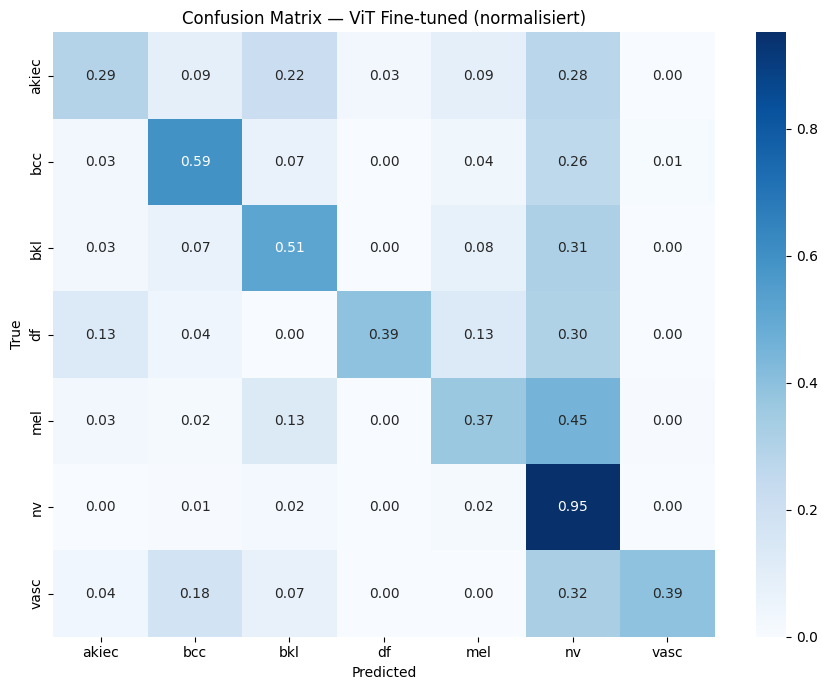

In [ ]:
# Section 5: Evaluation — ViT von HuggingFace laden (kein trainer nötig)
from transformers import AutoImageProcessor, pipeline

vit_processor_eval = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_pipe_eval = pipeline('image-classification', model=MODEL_NAME, image_processor=vit_processor_eval)

vit_preds = []
vit_labels_list = []

for _, row in df_test.iterrows():
    try:
        img = Image.open(str(row['image_path'])).convert('RGB')
        result = vit_pipe_eval(img)
        pred_label = result[0]['label']
        vit_preds.append(LABEL2ID[pred_label])
    except Exception:
        vit_preds.append(0)
    vit_labels_list.append(LABEL2ID[row['dx']])

vit_preds  = np.array(vit_preds)
vit_labels = np.array(vit_labels_list)

print('=== ViT (Fine-tuned) ===')
print(f'Accuracy:          {(vit_preds == vit_labels).mean():.3f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(vit_labels, vit_preds):.3f}')
print()
print(classification_report(vit_labels, vit_preds, target_names=CLASS_NAMES))


# Confusion Matrix
cm = confusion_matrix(vit_labels, vit_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — ViT Fine-tuned (normalisiert)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_01_vit_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modellvergleich: ViT vs. CLIP vs. OpenAI Vision

Gleicher Ansatz wie in Week 7 (Oxford Pets App).

In [ ]:
# Sample von 50 Testbildern für den Vergleich
sample_df = df_test.groupby('dx').apply(
    lambda x: x.sample(min(len(x), 7), random_state=42)
).reset_index(drop=True)

print(f'Vergleichs-Sample: {len(sample_df)} Bilder')
print(sample_df['dx'].value_counts())

Vergleichs-Sample: 49 Bilder
dx
akiec    7
bcc      7
bkl      7
df       7
mel      7
nv       7
vasc     7
Name: count, dtype: int64


/tmp/ipykernel_1144/3571760553.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_test.groupby('dx').apply(


In [ ]:
# --- Modell 1: Unser fine-tuned ViT (von HuggingFace) ---
from transformers import AutoImageProcessor

vit_processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_pipe = pipeline('image-classification', model=MODEL_NAME, image_processor=vit_processor)

def predict_vit(image_path):
    img = Image.open(image_path).convert('RGB')
    results = vit_pipe(img)
    return results[0]['label'], results[0]['score']

print('ViT Pipeline bereit.')

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Pipeline bereit.


In [ ]:
# --- Modell 2: CLIP Zero-Shot ---
clip_descriptions = [
    'actinic keratosis skin lesion',
    'basal cell carcinoma skin lesion',
    'benign keratosis skin lesion',
    'dermatofibroma skin lesion',
    'melanoma skin lesion',
    'melanocytic nevus mole',
    'vascular lesion skin'
]
clip_label_map = dict(zip(clip_descriptions, CLASS_NAMES))

clip_pipe = pipeline(model='openai/clip-vit-large-patch14', task='zero-shot-image-classification')

def predict_clip(image_path):
    img = Image.open(image_path).convert('RGB')
    results = clip_pipe(img, candidate_labels=clip_descriptions)
    best = results[0]
    return clip_label_map[best['label']], best['score']

print('CLIP Pipeline bereit.')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIP Pipeline bereit.


In [ ]:
# --- Modell 3: OpenAI Vision ---
import os
os.environ['OPENAI_API_KEY'] = 'YOUR_OPENAI_KEY'  # <-- deinen OpenAI Key hier eintragen

openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY')) if os.getenv('OPENAI_API_KEY') else None

def encode_image(image_path):
    with open(image_path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def predict_openai(image_path):
    prompt = (
        f'Classify this skin lesion image. Choose exactly one label from: {CLASS_NAMES}. '
        'Return valid JSON with keys: label (string), confidence (0-1), reasoning (string). '
        'Only use labels from the provided list.'
    )
    b64 = encode_image(image_path)
    response = openai_client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'text', 'text': prompt},
                {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}}
            ]
        }],
        max_tokens=200
    )
    raw = response.choices[0].message.content.strip()
    if raw.startswith('```'):
        raw = '\n'.join(raw.split('\n')[1:-1])
    parsed = json.loads(raw)
    label = parsed.get('label', 'nv')
    if label not in CLASS_NAMES:
        label = 'nv'
    return label, float(parsed.get('confidence', 0.5))

print('OpenAI Vision bereit.')

OpenAI Vision bereit.


In [ ]:
from tqdm import tqdm

vit_pred_list, clip_pred_list, openai_pred_list = [], [], []
true_labels = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    path = row['image_path']
    true_labels.append(row['dx'])

    # ViT
    try:
        pred, _ = predict_vit(path)
    except Exception:
        pred = 'nv'
    vit_pred_list.append(pred)

    # CLIP
    try:
        pred, _ = predict_clip(path)
    except Exception:
        pred = 'nv'
    clip_pred_list.append(pred)

    # OpenAI
    try:
        pred, _ = predict_openai(path)
    except Exception:
        pred = 'nv'
    openai_pred_list.append(pred)

print('Alle Vorhersagen gesammelt.')

100%|██████████| 49/49 [06:24<00:00,  7.84s/it]

Alle Vorhersagen gesammelt.


## 7. Vergleichs-Tabelle

          Modell  Accuracy  Balanced Accuracy  F1 Macro Training nötig         Kosten
ViT (Fine-tuned)     0.449              0.449     0.427             Ja Einmalig (GPU)
CLIP (Zero-Shot)     0.163              0.163     0.116           Nein      Kostenlos
   OpenAI Vision     0.265              0.265     0.191           Nein   Per API Call


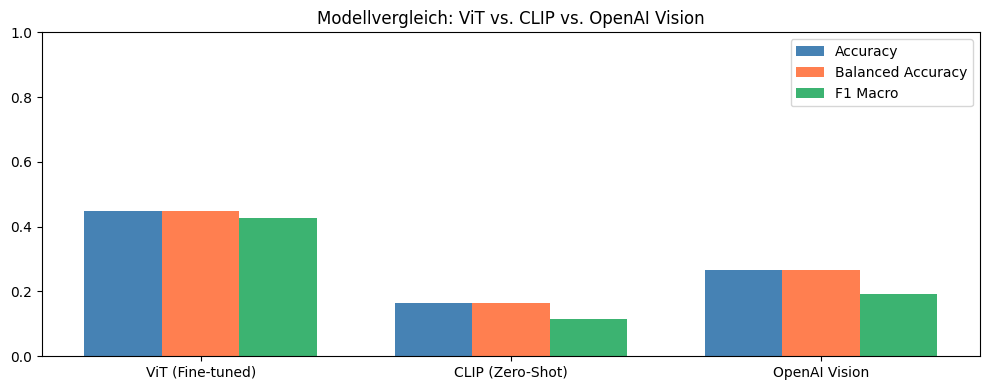

In [ ]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame({
    'Modell': ['ViT (Fine-tuned)', 'CLIP (Zero-Shot)', 'OpenAI Vision'],
    'Accuracy': [
        (np.array(vit_pred_list) == np.array(true_labels)).mean(),
        (np.array(clip_pred_list) == np.array(true_labels)).mean(),
        (np.array(openai_pred_list) == np.array(true_labels)).mean(),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(true_labels, vit_pred_list),
        balanced_accuracy_score(true_labels, clip_pred_list),
        balanced_accuracy_score(true_labels, openai_pred_list),
    ],
    'F1 Macro': [
        f1_score(true_labels, vit_pred_list, average='macro', labels=CLASS_NAMES, zero_division=0),
        f1_score(true_labels, clip_pred_list, average='macro', labels=CLASS_NAMES, zero_division=0),
        f1_score(true_labels, openai_pred_list, average='macro', labels=CLASS_NAMES, zero_division=0),
    ],
    'Training nötig': ['Ja', 'Nein', 'Nein'],
    'Kosten': ['Einmalig (GPU)', 'Kostenlos', 'Per API Call']
}).round(3)

print(comparison.to_string(index=False))

# Balkendiagramm
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(3)
w = 0.25
ax.bar(x - w, comparison['Accuracy'], w, label='Accuracy', color='steelblue')
ax.bar(x,     comparison['Balanced Accuracy'], w, label='Balanced Accuracy', color='coral')
ax.bar(x + w, comparison['F1 Macro'], w, label='F1 Macro', color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Modell'])
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Modellvergleich: ViT vs. CLIP vs. OpenAI Vision')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Beispielbilder mit Vorhersagen aller 3 Modelle

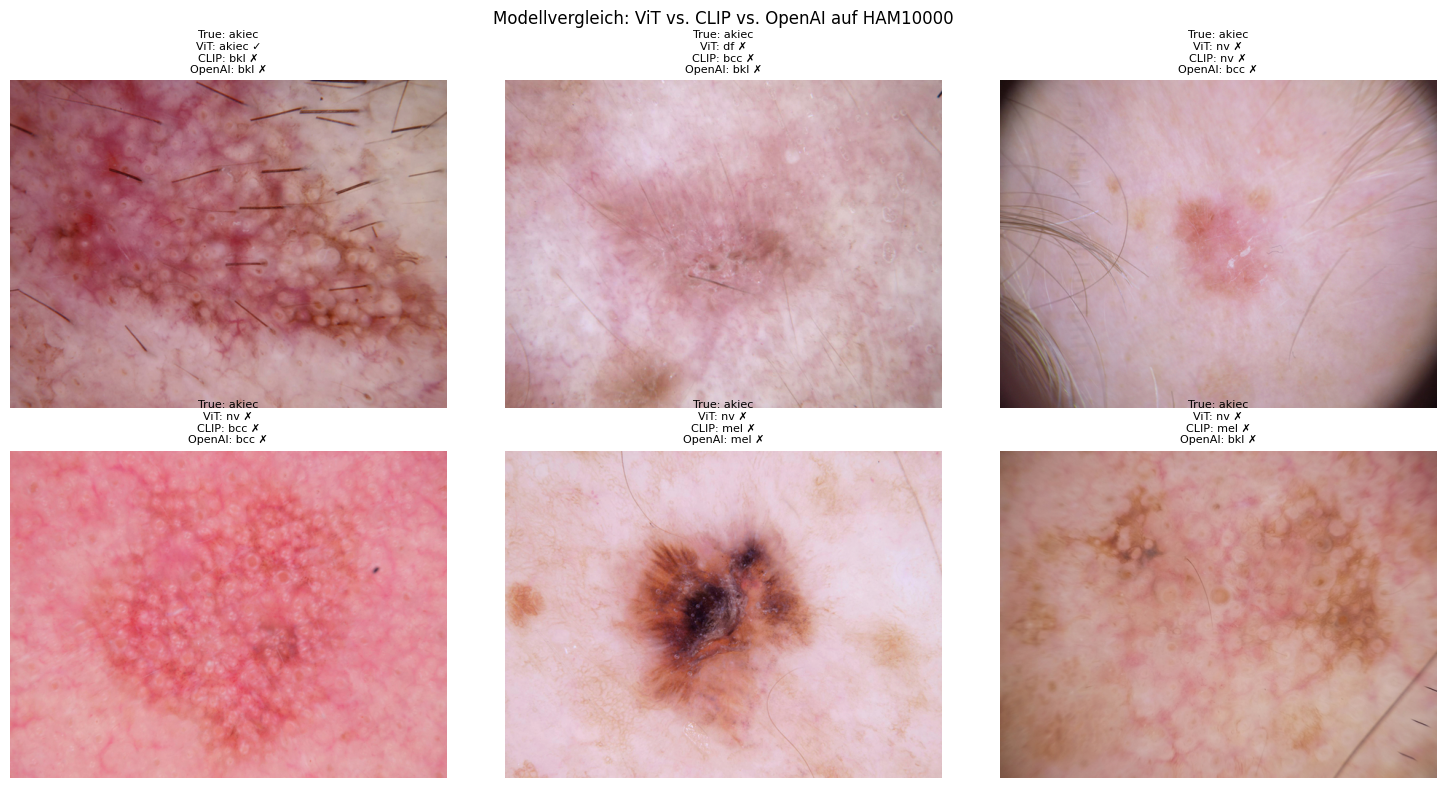

In [ ]:
show_n = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    if i >= len(sample_df):
        ax.axis('off')
        continue
    row = sample_df.iloc[i]
    img = Image.open(str(row['image_path']))
    true = str(row['dx'])
    vit  = vit_pred_list[i]
    clip = clip_pred_list[i]
    oai  = openai_pred_list[i]

    ax.imshow(img)
    ax.set_title(
        f'True: {true}\n'
        f'ViT: {vit} {"✓" if vit==true else "✗"}\n'
        f'CLIP: {clip} {"✓" if clip==true else "✗"}\n'
        f'OpenAI: {oai} {"✓" if oai==true else "✗"}',
        fontsize=8
    )
    ax.axis('off')

plt.suptitle('Modellvergleich: ViT vs. CLIP vs. OpenAI auf HAM10000', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_03_sample_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 9. Zusammenfassung

**Ergebnisse:**

| Modell | Stärken | Schwächen |
|---|---|---|
| **ViT (Fine-tuned)** | Beste Performance auf HAM10000 | Training nötig, GPU erforderlich |
| **CLIP (Zero-Shot)** | Kein Training, sofort einsetzbar | Schlechtere Performance, kennt keine Hautlasionen direkt |
| **OpenAI Vision** | Gute Begründungen, flexibel | Kosten pro API Call, Datenschutz |

**Wahl für die App:** Unser fine-tuned ViT — beste Performance und keine laufenden Kosten.

**Integration in die Pipeline:**
Der ViT-Output (Läsionsklasse + Konfidenz) wird in Notebook 05 mit dem ML risk_level kombiniert.

**Nächster Schritt:** Notebook 04 — NLP Erklärungen